# 03 - Xét nghiệm, tiền sử y tế, chẩn đoán và thuốc

**Mục tiêu:** phân tích các biến y tế chuyên sâu hơn để phục vụ các bước sau như phân loại, phân cụm và luật kết hợp.

Các nhóm biến chính trong file này:
- Xét nghiệm/điều trị: `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`
- Tiền sử y tế: `number_outpatient`, `number_emergency`, `number_inpatient`
- Xét nghiệm A1C/glucose: `A1Cresult`, `max_glu_serum`
- Thuốc: `metformin`, `glipizide`, `glyburide`, `pioglitazone`, `insulin`
- Chẩn đoán: `diag_1`, `diag_2`, `diag_3`
- Nhãn mục tiêu: `readmitted`

## 1. Load dữ liệu

Đọc lại `diabetic_data.csv`, chuyển dấu `?` thành missing value và tạo thêm `readmitted_binary` để tiện so sánh có/không tái nhập viện.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Thiết lập hiển thị bảng và biểu đồ.
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="Set2")

# Notebook nằm trong thư mục Exploratory Data Analysis, file CSV nằm ở thư mục gốc project.
data_candidates = [
    Path("diabetic_data.csv"),
    Path("..") / "diabetic_data.csv",
]

data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Không tìm thấy diabetic_data.csv. Hãy kiểm tra lại vị trí file dữ liệu.")

# na_values='?' giúp pandas chuyển các dấu ? thành NaN.
df = pd.read_csv(data_path, na_values="?")

# Tạo nhãn nhị phân để dùng cho so sánh/tương quan.
df["readmitted_binary"] = np.where(df["readmitted"].eq("NO"), 0, 1)

print(f"Đã đọc dữ liệu từ: {data_path.resolve()}")
print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]:,} cột")
df.head()

Đã đọc dữ liệu từ: D:\HocTap\KT&XLTT\CUOIKI\diabetic_data.csv
Kích thước dữ liệu: 101,766 dòng x 51 cột


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9880\3025004026.py:26: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, na_values="?")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,1
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,0


### Hàm hỗ trợ biểu đồ

Các hàm này giúp vẽ stacked bar và bảng tần suất lặp lại nhiều lần trong notebook.

In [2]:
readmitted_order = ["NO", ">30", "<30"]

def frequency_table(data, col):
    # Bảng tần suất cho biến phân loại.
    return (
        data[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
        .assign(percent=lambda x: x["count"] / len(data) * 100)
    )

def plot_stacked_readmitted(data, col, title, normalize=True, figsize=(9, 5), rotation=45):
    # Stacked bar cho biết phân bố readmitted trong từng nhóm của biến phân loại.
    cross_tab = pd.crosstab(data[col], data["readmitted"])
    cross_tab = cross_tab.reindex(columns=readmitted_order, fill_value=0)
    if normalize:
        plot_data = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
        ylabel = "Tỷ lệ (%)"
    else:
        plot_data = cross_tab
        ylabel = "Số dòng"

    ax = plot_data.plot(kind="bar", stacked=True, figsize=figsize, colormap="Set2")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel(ylabel)
    ax.legend(title="readmitted", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=rotation, ha="right" if rotation else "center")
    plt.tight_layout()
    plt.show()

def plot_top_count(data, col, title, top_n=10, figsize=(10, 5)):
    # Vẽ top N giá trị phổ biến nhất của một cột.
    order = data[col].value_counts(dropna=False).head(top_n).index
    plt.figure(figsize=figsize)
    sns.countplot(data=data[data[col].isin(order)], y=col, order=order, color="#4C78A8")
    plt.title(title)
    plt.xlabel("Số dòng")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 2. EDA biến xét nghiệm/điều trị

Các biến số chính:
- `num_lab_procedures`: số xét nghiệm lab.
- `num_procedures`: số thủ thuật/phẫu thuật.
- `num_medications`: số loại thuốc được kê.
- `number_diagnoses`: số chẩn đoán được ghi nhận.

In [3]:
medical_numeric_cols = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses",
]

df[medical_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_lab_procedures,101766.00,43.10,19.67,1.00,31.00,44.00,57.00,132.00
num_procedures,101766.00,1.34,1.71,0.00,0.00,1.00,2.00,6.00
num_medications,101766.00,16.02,8.13,1.00,10.00,15.00,20.00,81.00
number_diagnoses,101766.00,7.42,1.93,1.00,6.00,8.00,9.00,16.00


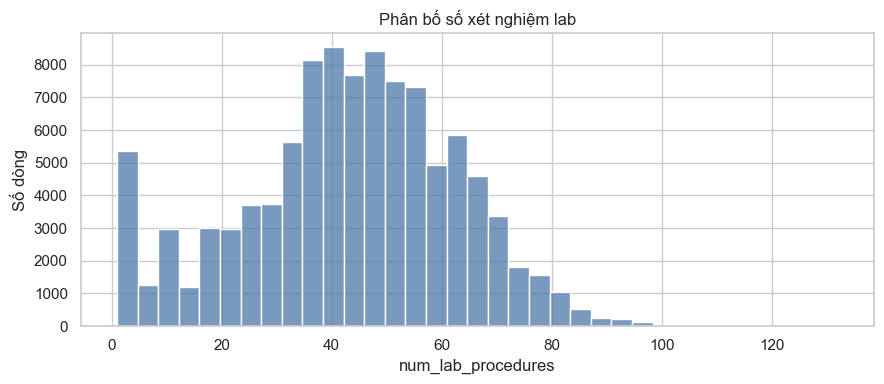

In [4]:
# Histogram num_lab_procedures.
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x="num_lab_procedures", bins=35, color="#4C78A8")
plt.title("Phân bố số xét nghiệm lab")
plt.xlabel("num_lab_procedures")
plt.ylabel("Số dòng")
plt.tight_layout()
plt.show()

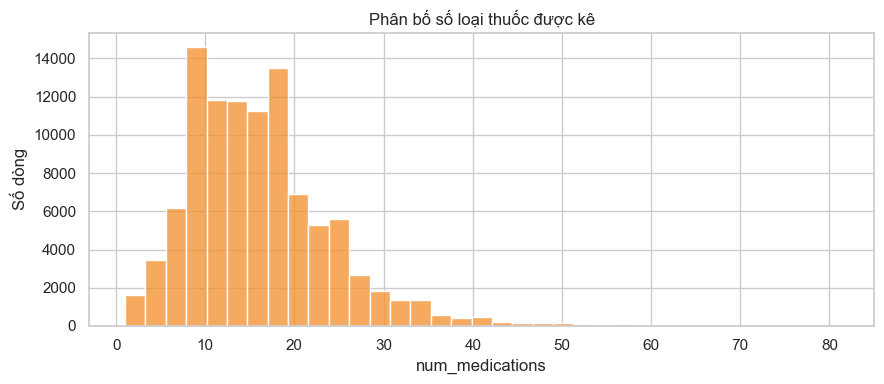

In [5]:
# Histogram num_medications.
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x="num_medications", bins=35, color="#F28E2B")
plt.title("Phân bố số loại thuốc được kê")
plt.xlabel("num_medications")
plt.ylabel("Số dòng")
plt.tight_layout()
plt.show()

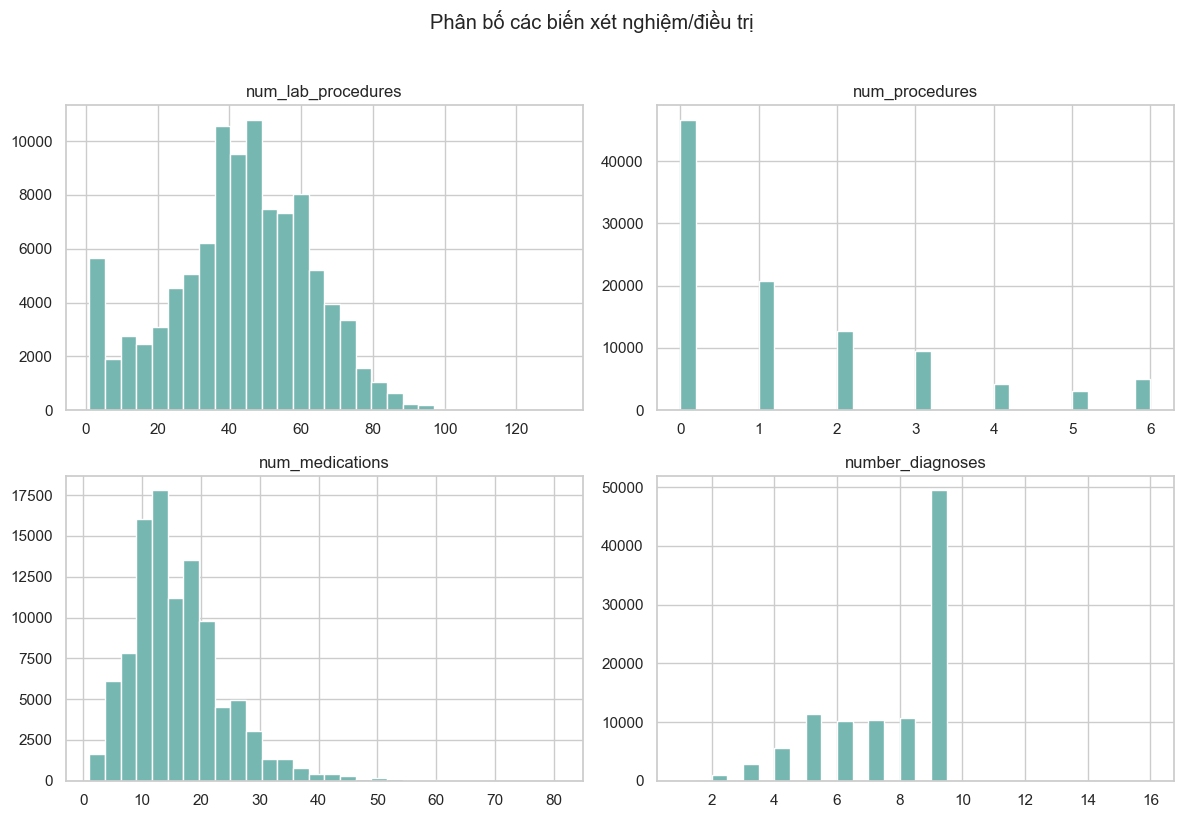

In [6]:
# Histogram nhanh cho toàn bộ biến xét nghiệm/điều trị.
df[medical_numeric_cols].hist(figsize=(12, 8), bins=30, color="#76B7B2")
plt.suptitle("Phân bố các biến xét nghiệm/điều trị", y=1.02)
plt.tight_layout()
plt.show()

## 3. So sánh theo `readmitted`

Tính trung bình các biến y tế theo từng nhóm `readmitted` để xem nhóm tái nhập viện có xu hướng được xét nghiệm/điều trị nhiều hơn hay không.

In [7]:
medical_mean_by_readmitted = (
    df.groupby("readmitted")[medical_numeric_cols]
    .mean()
    .reindex(readmitted_order)
)

medical_mean_by_readmitted

,num_lab_procedures,num_procedures,num_medications,number_diagnoses
readmitted,,,,
NO,42.38,1.41,15.67,7.22
>30,43.84,1.25,16.28,7.65
<30,44.23,1.28,16.90,7.69


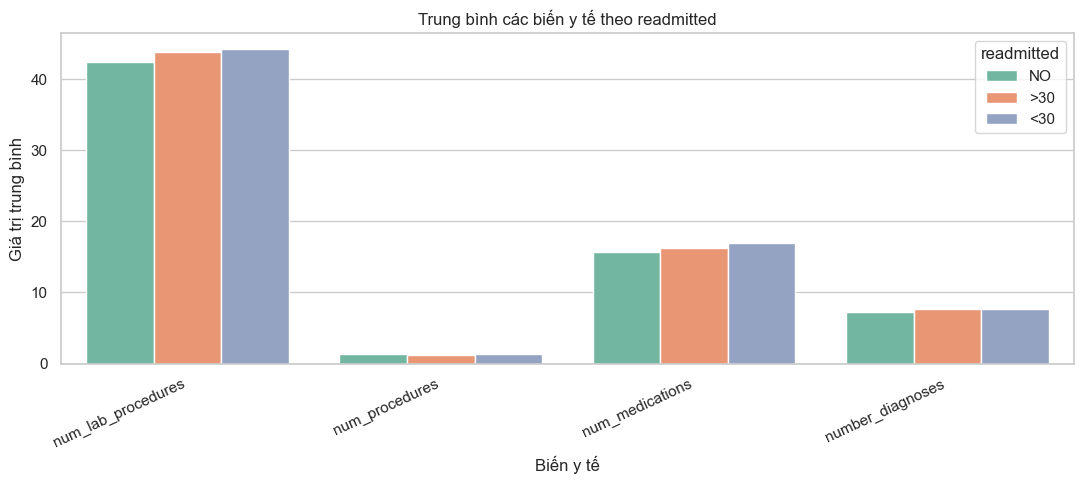

In [8]:
# Bar chart mean medical features by readmitted.
medical_mean_long = medical_mean_by_readmitted.reset_index().melt(
    id_vars="readmitted",
    var_name="feature",
    value_name="mean_value",
)

plt.figure(figsize=(11, 5))
sns.barplot(data=medical_mean_long, x="feature", y="mean_value", hue="readmitted")
plt.title("Trung bình các biến y tế theo readmitted")
plt.xlabel("Biến y tế")
plt.ylabel("Giá trị trung bình")
plt.xticks(rotation=25, ha="right")
plt.legend(title="readmitted")
plt.tight_layout()
plt.show()

**Nhận xét:** nếu nhóm `<30` hoặc `>30` có trung bình `num_medications`, `num_lab_procedures`, `number_diagnoses` cao hơn nhóm `NO`, các biến này có thể liên quan đến mức độ phức tạp của bệnh và nên giữ cho mô hình.

## 4. EDA tiền sử y tế

Các biến tiền sử sử dụng dịch vụ y tế trước lần nhập viện hiện tại:
- `number_outpatient`: số lần khám ngoại trú trước đó.
- `number_emergency`: số lần vào cấp cứu trước đó.
- `number_inpatient`: số lần nhập viện nội trú trước đó.

In [9]:
previous_visit_cols = ["number_outpatient", "number_emergency", "number_inpatient"]
df[previous_visit_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
number_outpatient,101766.00,0.37,1.27,0.00,0.00,0.00,0.00,42.00
number_emergency,101766.00,0.20,0.93,0.00,0.00,0.00,0.00,76.00
number_inpatient,101766.00,0.64,1.26,0.00,0.00,0.00,1.00,21.00


In [10]:
previous_visit_mean = (
    df.groupby("readmitted")[previous_visit_cols]
    .mean()
    .reindex(readmitted_order)
)

previous_visit_mean

,number_outpatient,number_emergency,number_inpatient
readmitted,,,
NO,0.27,0.11,0.38
>30,0.50,0.28,0.84
<30,0.44,0.36,1.22


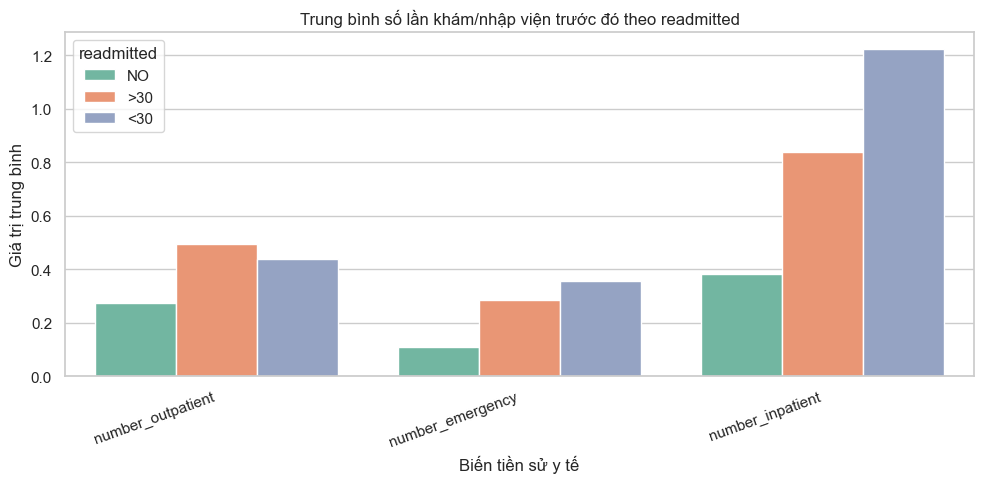

In [11]:
# Bar chart previous visits by readmitted.
previous_visit_long = previous_visit_mean.reset_index().melt(
    id_vars="readmitted",
    var_name="feature",
    value_name="mean_value",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=previous_visit_long, x="feature", y="mean_value", hue="readmitted")
plt.title("Trung bình số lần khám/nhập viện trước đó theo readmitted")
plt.xlabel("Biến tiền sử y tế")
plt.ylabel("Giá trị trung bình")
plt.xticks(rotation=20, ha="right")
plt.legend(title="readmitted")
plt.tight_layout()
plt.show()

**Nhận xét:** `number_inpatient` thường là biến rất đáng chú ý vì bệnh nhân từng nhập viện nhiều lần có thể có nguy cơ tái nhập viện cao hơn.

## 5. EDA A1C và glucose

Phân tích `A1Cresult` và `max_glu_serum`. Hai biến này có nhiều giá trị `None`, nghĩa là không có xét nghiệm hoặc không ghi nhận kết quả trong lần nhập viện.

In [12]:
lab_result_cols = ["A1Cresult", "max_glu_serum"]

for col in lab_result_cols:
    print(f"\n===== {col} =====")
    display(frequency_table(df, col))


===== A1Cresult =====


,A1Cresult,count,percent
0,NaN,84748,83.28
1,>8,8216,8.07
2,Norm,4990,4.90
3,>7,3812,3.75



===== max_glu_serum =====


,max_glu_serum,count,percent
0,NaN,96420,94.75
1,Norm,2597,2.55
2,>200,1485,1.46
3,>300,1264,1.24


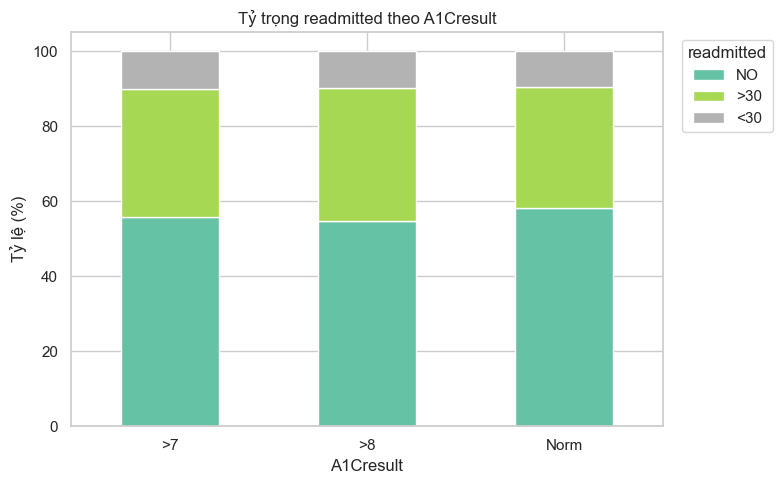

In [13]:
# Stacked bar A1Cresult vs readmitted.
plot_stacked_readmitted(df, "A1Cresult", "Tỷ trọng readmitted theo A1Cresult", normalize=True, figsize=(8, 5), rotation=0)

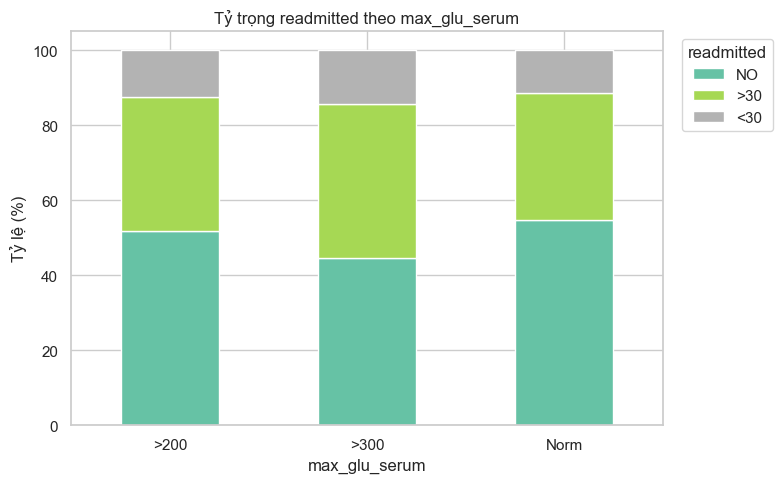

In [14]:
# Stacked bar max_glu_serum vs readmitted.
plot_stacked_readmitted(df, "max_glu_serum", "Tỷ trọng readmitted theo max_glu_serum", normalize=True, figsize=(8, 5), rotation=0)

## 6. EDA thuốc phổ biến

Tập trung vào một số thuốc phổ biến/quan trọng: `insulin`, `metformin`, `glipizide`, `glyburide`, `pioglitazone`.

In [15]:
drug_cols = ["insulin", "metformin", "glipizide", "glyburide", "pioglitazone"]

for col in drug_cols:
    print(f"\n===== {col} =====")
    display(frequency_table(df, col))


===== insulin =====


,insulin,count,percent
0,No,47383,46.56
1,Steady,30849,30.31
2,Down,12218,12.01
3,Up,11316,11.12



===== metformin =====


,metformin,count,percent
0,No,81778,80.36
1,Steady,18346,18.03
2,Up,1067,1.05
3,Down,575,0.57



===== glipizide =====


,glipizide,count,percent
0,No,89080,87.53
1,Steady,11356,11.16
2,Up,770,0.76
3,Down,560,0.55



===== glyburide =====


,glyburide,count,percent
0,No,91116,89.53
1,Steady,9274,9.11
2,Up,812,0.80
3,Down,564,0.55



===== pioglitazone =====


,pioglitazone,count,percent
0,No,94438,92.80
1,Steady,6976,6.85
2,Up,234,0.23
3,Down,118,0.12


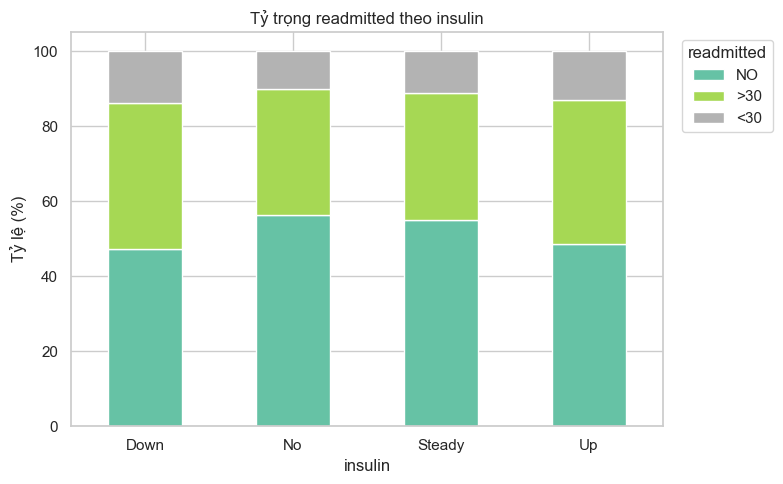

In [16]:
# Stacked bar insulin vs readmitted.
plot_stacked_readmitted(df, "insulin", "Tỷ trọng readmitted theo insulin", normalize=True, figsize=(8, 5), rotation=0)

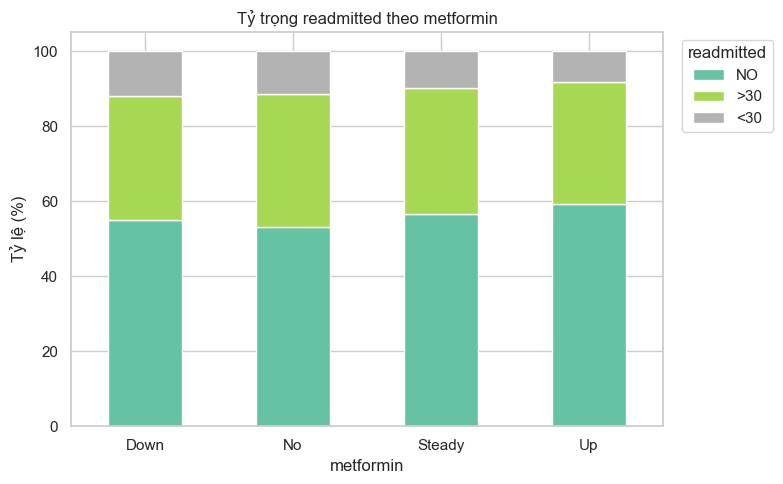

In [17]:
# Stacked bar metformin vs readmitted.
plot_stacked_readmitted(df, "metformin", "Tỷ trọng readmitted theo metformin", normalize=True, figsize=(8, 5), rotation=0)

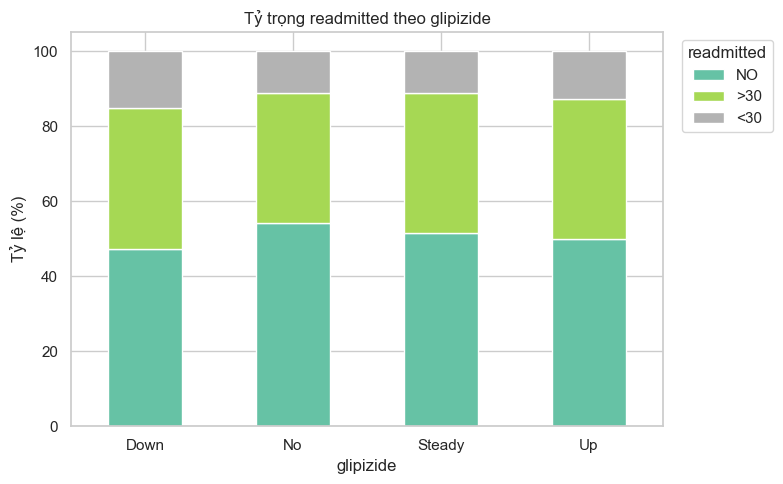

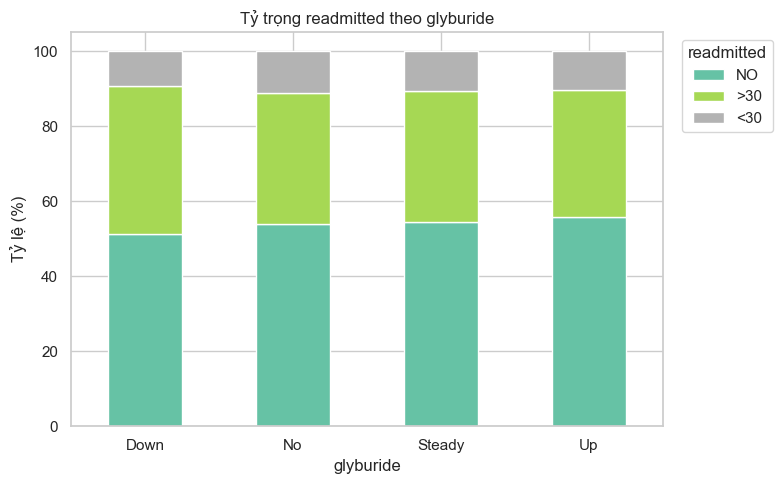

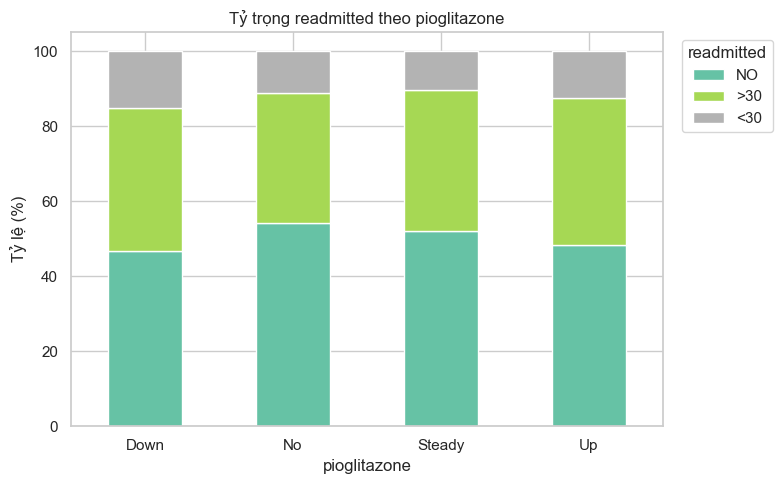

In [18]:
# Vẽ thêm các thuốc còn lại để so sánh nhanh.
for col in ["glipizide", "glyburide", "pioglitazone"]:
    plot_stacked_readmitted(df, col, f"Tỷ trọng readmitted theo {col}", normalize=True, figsize=(8, 5), rotation=0)

**Nhận xét:** trạng thái `Up`, `Down`, `Steady`, `No` cho biết thuốc có được tăng/giảm/giữ nguyên hay không. Các biến thuốc có thể dùng cho phân loại và đặc biệt hữu ích khi tạo itemset cho luật kết hợp.

## 7. EDA thay đổi thuốc

Phân tích `change` và `diabetesMed` để xem việc thay đổi thuốc hoặc có kê thuốc tiểu đường có liên quan đến tái nhập viện hay không.

In [19]:
for col in ["change", "diabetesMed"]:
    print(f"\n===== {col} =====")
    display(frequency_table(df, col))


===== change =====


,change,count,percent
0,No,54755,53.80
1,Ch,47011,46.20



===== diabetesMed =====


,diabetesMed,count,percent
0,Yes,78363,77.00
1,No,23403,23.00


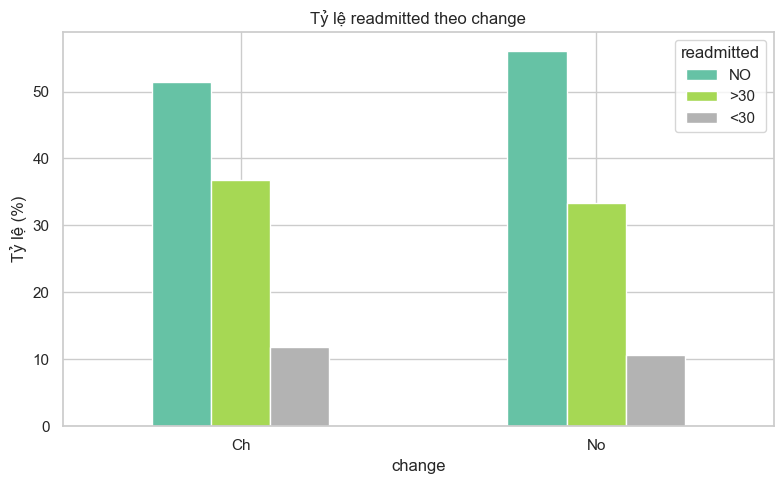

In [20]:
# Bar chart change vs readmitted.
change_tab = pd.crosstab(df["change"], df["readmitted"], normalize="index") * 100
change_tab = change_tab.reindex(columns=readmitted_order, fill_value=0)

ax = change_tab.plot(kind="bar", figsize=(8, 5), colormap="Set2")
ax.set_title("Tỷ lệ readmitted theo change")
ax.set_xlabel("change")
ax.set_ylabel("Tỷ lệ (%)")
ax.legend(title="readmitted")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

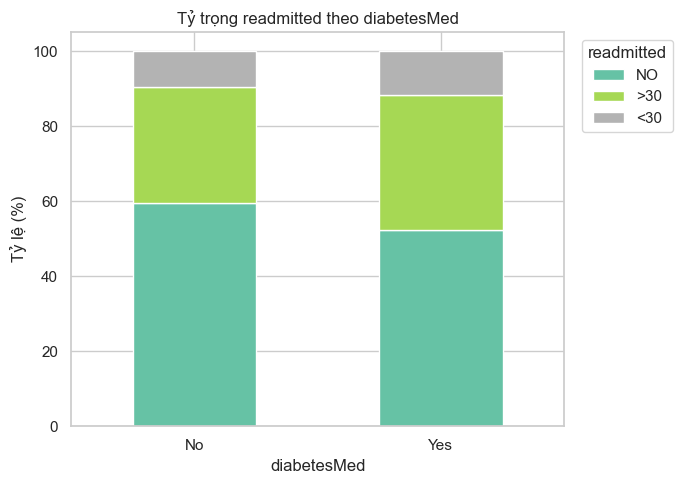

In [21]:
plot_stacked_readmitted(df, "diabetesMed", "Tỷ trọng readmitted theo diabetesMed", normalize=True, figsize=(7, 5), rotation=0)

## 8. EDA chẩn đoán

`diag_1`, `diag_2`, `diag_3` là các mã chẩn đoán ICD-9. Trước khi gom nhóm, xem top mã xuất hiện nhiều nhất.

In [22]:
diag_cols = ["diag_1", "diag_2", "diag_3"]

for col in diag_cols:
    print(f"\n===== Top 10 {col} =====")
    display(frequency_table(df, col).head(10))


===== Top 10 diag_1 =====


,diag_1,count,percent
0,428,6862,6.74
1,414,6581,6.47
2,786,4016,3.95
3,410,3614,3.55
4,486,3508,3.45
5,427,2766,2.72
6,491,2275,2.24
7,715,2151,2.11
8,682,2042,2.01
9,434,2028,1.99



===== Top 10 diag_2 =====


,diag_2,count,percent
0,276,6752,6.63
1,428,6662,6.55
2,250,6071,5.97
3,427,5036,4.95
4,401,3736,3.67
5,496,3305,3.25
6,599,3288,3.23
7,403,2823,2.77
8,414,2650,2.60
9,411,2566,2.52



===== Top 10 diag_3 =====


,diag_3,count,percent
0,250,11555,11.35
1,401,8289,8.15
2,276,5175,5.09
3,428,4577,4.50
4,427,3955,3.89
5,414,3664,3.60
6,496,2605,2.56
7,403,2357,2.32
8,585,1992,1.96
9,272,1969,1.93


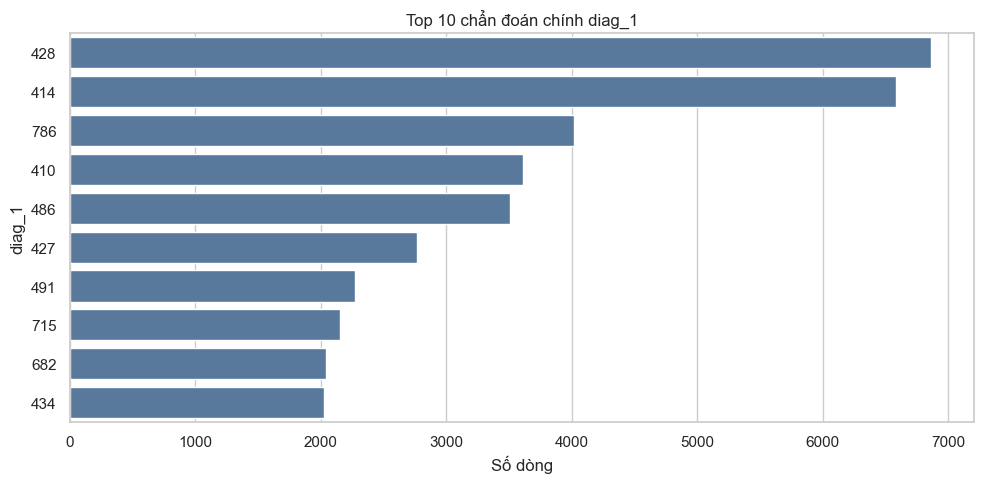

In [23]:
# Top 10 diag_1.
plot_top_count(df, "diag_1", "Top 10 chẩn đoán chính diag_1", top_n=10, figsize=(10, 5))

## 9. Gom nhóm ICD-9

Mã ICD-9 chi tiết có rất nhiều giá trị. Gom nhóm giúp giảm số chiều và dễ diễn giải hơn khi làm mô hình, phân cụm hoặc luật kết hợp.

In [24]:
def icd9_group(code):
    # Gom nhóm ICD-9 theo các nhóm bệnh lớn thường dùng trong EDA dataset diabetes.
    if pd.isna(code):
        return "Missing"

    code_str = str(code).strip()
    if code_str == "":
        return "Missing"

    # Mã bắt đầu bằng V/E là nhóm yếu tố bổ sung hoặc nguyên nhân bên ngoài.
    if code_str.startswith("V"):
        return "Supplementary"
    if code_str.startswith("E"):
        return "External causes"

    try:
        numeric_code = float(code_str)
    except ValueError:
        return "Other"

    if 390 <= numeric_code <= 459 or numeric_code == 785:
        return "Circulatory"
    if 460 <= numeric_code <= 519 or numeric_code == 786:
        return "Respiratory"
    if 520 <= numeric_code <= 579 or numeric_code == 787:
        return "Digestive"
    if numeric_code == 250 or str(code_str).startswith("250"):
        return "Diabetes"
    if 800 <= numeric_code <= 999:
        return "Injury"
    if 710 <= numeric_code <= 739:
        return "Musculoskeletal"
    if 580 <= numeric_code <= 629 or numeric_code == 788:
        return "Genitourinary"
    if 140 <= numeric_code <= 239:
        return "Neoplasms"
    return "Other"

for col in diag_cols:
    df[f"{col}_group"] = df[col].apply(icd9_group)

df[["diag_1", "diag_1_group", "diag_2", "diag_2_group", "diag_3", "diag_3_group"]].head()

,diag_1,diag_1_group,diag_2,diag_2_group,diag_3,diag_3_group
0,250.83,Diabetes,NaN,Missing,NaN,Missing
1,276,Other,250.01,Diabetes,255,Other
2,648,Other,250,Diabetes,V27,Supplementary
3,8,Other,250.43,Diabetes,403,Circulatory
4,197,Neoplasms,157,Neoplasms,250,Diabetes


In [25]:
for col in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    print(f"\n===== {col} =====")
    display(frequency_table(df, col))


===== diag_1_group =====


,diag_1_group,count,percent
0,Circulatory,30437,29.91
1,Other,16527,16.24
2,Respiratory,14423,14.17
3,Digestive,9475,9.31
4,Diabetes,8757,8.61
5,Injury,6974,6.85
6,Genitourinary,5117,5.03
7,Musculoskeletal,4957,4.87
8,Neoplasms,3433,3.37
9,Supplementary,1644,1.62



===== diag_2_group =====


,diag_2_group,count,percent
0,Circulatory,31881,31.33
1,Other,24017,23.60
2,Diabetes,12794,12.57
3,Respiratory,10895,10.71
4,Genitourinary,8376,8.23
5,Digestive,4170,4.10
6,Neoplasms,2547,2.50
7,Injury,2428,2.39
8,Supplementary,1805,1.77
9,Musculoskeletal,1764,1.73



===== diag_3_group =====


,diag_3_group,count,percent
0,Circulatory,30306,29.78
1,Other,24137,23.72
2,Diabetes,17157,16.86
3,Respiratory,7358,7.23
4,Genitourinary,6680,6.56
5,Digestive,3930,3.86
6,Supplementary,3814,3.75
7,Injury,1946,1.91
8,Musculoskeletal,1915,1.88
9,Neoplasms,1856,1.82


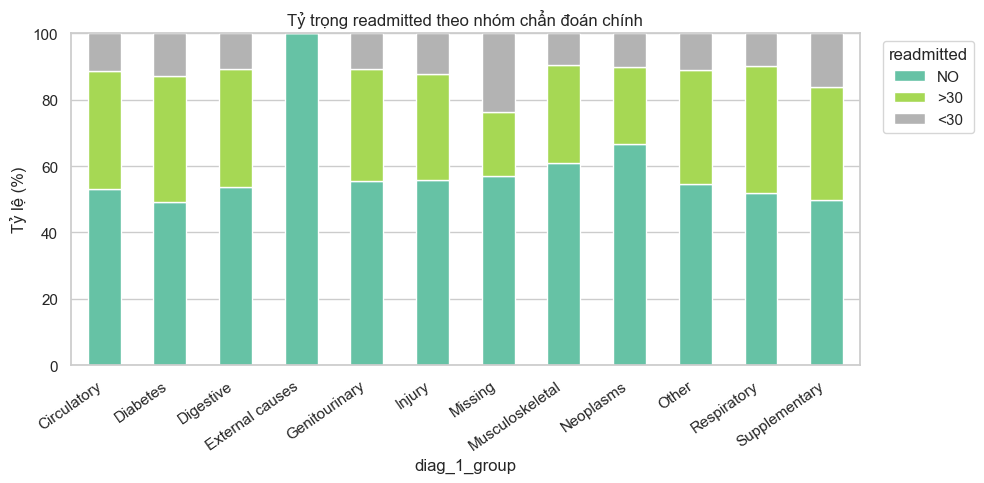

In [26]:
plot_stacked_readmitted(df, "diag_1_group", "Tỷ trọng readmitted theo nhóm chẩn đoán chính", normalize=True, figsize=(10, 5), rotation=35)

## 10. Outlier

Dùng boxplot để kiểm tra outlier ở các biến số. Với các biến đếm như số lần khám/nhập viện trước đó, outlier có thể là tín hiệu quan trọng chứ không nhất thiết phải xóa.

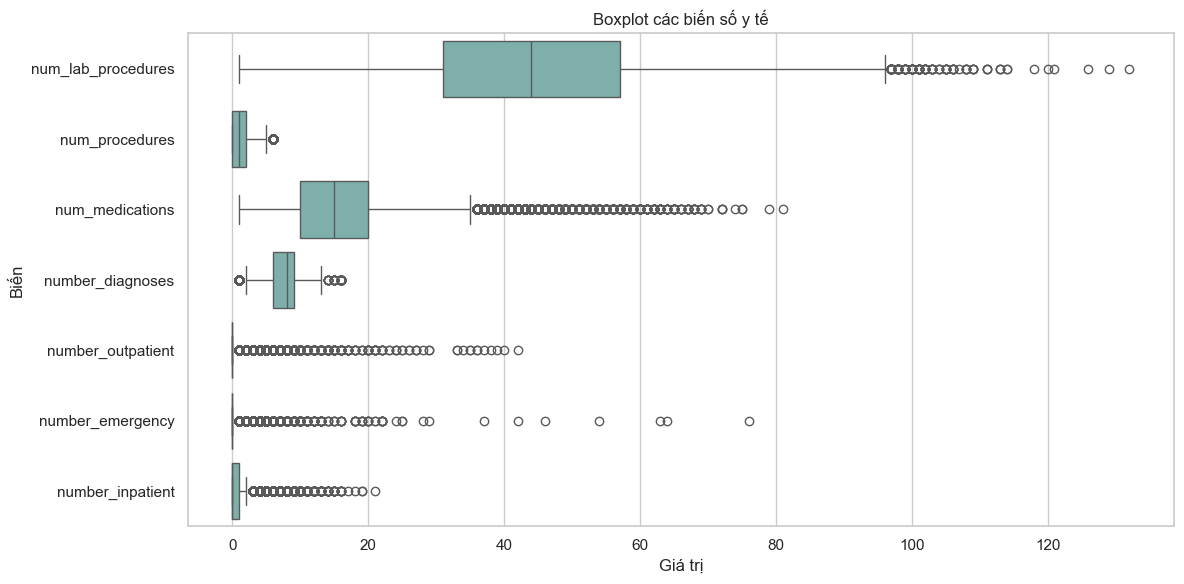

In [27]:
numeric_cols = medical_numeric_cols + previous_visit_cols

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols], orient="h", color="#76B7B2")
plt.title("Boxplot các biến số y tế")
plt.xlabel("Giá trị")
plt.ylabel("Biến")
plt.tight_layout()
plt.show()

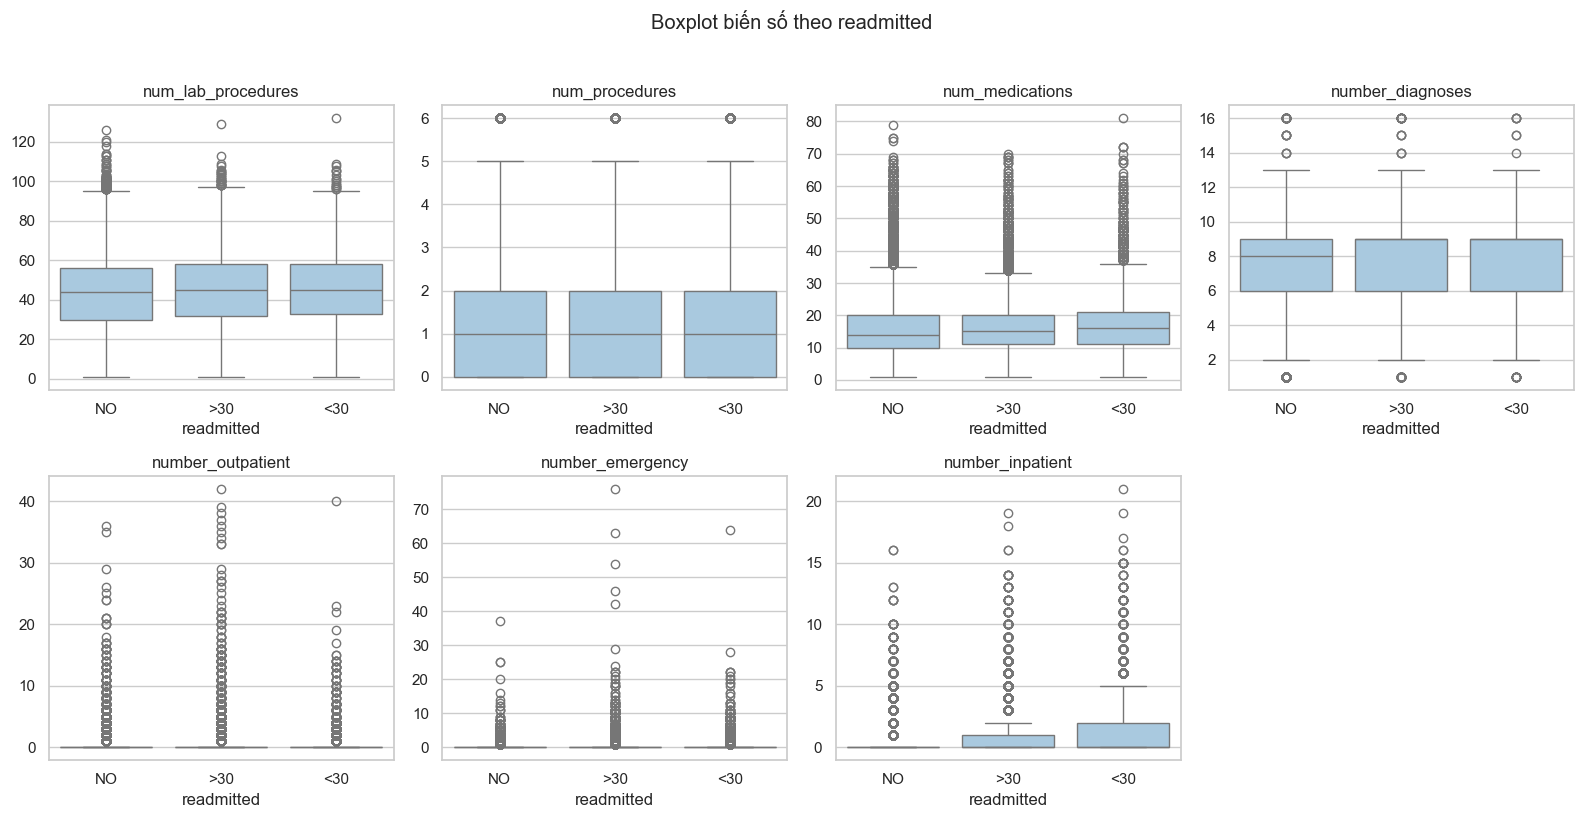

In [28]:
# Boxplot theo readmitted để xem nhóm tái nhập viện có nhiều outlier hơn không.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="readmitted", y=col, order=readmitted_order, ax=ax, color="#A0CBE8")
    ax.set_title(col)
    ax.set_xlabel("readmitted")
    ax.set_ylabel("")

# Nếu số subplot nhiều hơn số biến, ẩn ô thừa.
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.suptitle("Boxplot biến số theo readmitted", y=1.02)
plt.tight_layout()
plt.show()

## 11. Correlation matrix

Tính tương quan giữa các biến số và `readmitted_binary`. Vì đây là tương quan tuyến tính đơn giản, kết quả chỉ nên dùng để định hướng, không thay thế mô hình.

In [29]:
corr_cols = numeric_cols + ["readmitted_binary"]
corr_matrix = df[corr_cols].corr()
corr_matrix

,num_lab_procedures,num_procedures,num_medications,number_diagnoses,number_outpatient,number_emergency,number_inpatient,readmitted_binary
num_lab_procedures,1.00,0.06,0.27,0.15,-0.01,-0.00,0.04,0.04
num_procedures,0.06,1.00,0.39,0.07,-0.02,-0.04,-0.07,-0.04
num_medications,0.27,0.39,1.00,0.26,0.05,0.01,0.06,0.05
number_diagnoses,0.15,0.07,0.26,1.00,0.09,0.06,0.10,0.11
number_outpatient,-0.01,-0.02,0.05,0.09,1.00,0.09,0.11,0.08
number_emergency,-0.00,-0.04,0.01,0.06,0.09,1.00,0.27,0.10
number_inpatient,0.04,-0.07,0.06,0.10,0.11,0.27,1.00,0.22
readmitted_binary,0.04,-0.04,0.05,0.11,0.08,0.10,0.22,1.00


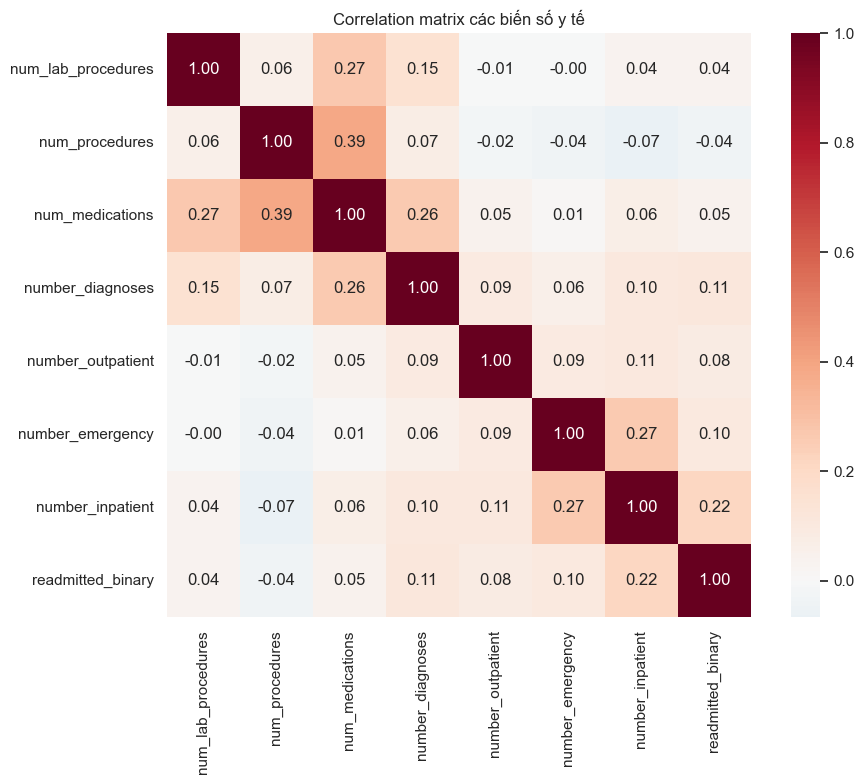

In [30]:
# Correlation matrix.
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix các biến số y tế")
plt.tight_layout()
plt.show()

In [31]:
# Xem riêng tương quan với nhãn nhị phân.
corr_with_target = (
    corr_matrix["readmitted_binary"]
    .drop("readmitted_binary")
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame("corr_with_readmitted_binary")
)

corr_with_target

,corr_with_readmitted_binary
number_inpatient,0.22
number_diagnoses,0.11
number_emergency,0.10
number_outpatient,0.08
num_medications,0.05
num_procedures,-0.04
num_lab_procedures,0.04


## 12. Kết luận file 3

Tổng hợp các đặc trưng quan trọng nên cân nhắc cho mô hình phân loại, phân cụm và luật kết hợp.

In [32]:
# Bảng đề xuất feature cho các bước tiếp theo.
feature_recommendation = pd.DataFrame({
    "nhom_feature": [
        "Xét nghiệm/điều trị",
        "Tiền sử y tế",
        "A1C/glucose",
        "Thuốc phổ biến",
        "Thay đổi thuốc",
        "Chẩn đoán gốc",
        "Chẩn đoán gom nhóm",
    ],
    "cot_de_xuat": [
        ", ".join(medical_numeric_cols),
        ", ".join(previous_visit_cols),
        "A1Cresult, max_glu_serum",
        ", ".join(drug_cols),
        "change, diabetesMed",
        "diag_1, diag_2, diag_3",
        "diag_1_group, diag_2_group, diag_3_group",
    ],
    "ly_do": [
        "Phản ánh mức độ xét nghiệm, điều trị và độ phức tạp của ca bệnh.",
        "Lịch sử sử dụng dịch vụ y tế trước đó, thường liên quan mạnh đến tái nhập viện.",
        "Phản ánh kiểm soát đường huyết và việc có xét nghiệm hay không.",
        "Có giá trị cho mô hình và có thể chuyển thành item cho luật kết hợp.",
        "Cho biết liệu phác đồ điều trị tiểu đường có thay đổi hay không.",
        "Giữ thông tin chi tiết nhưng số chiều lớn, cần encoding/cắt top mã.",
        "Giảm số chiều, dễ diễn giải, phù hợp hơn cho phân cụm và luật kết hợp.",
    ],
})

feature_recommendation

,nhom_feature,cot_de_xuat,ly_do
0,Xét nghiệm/điều trị,"num_lab_procedures, num_procedures, num_medica...","Phản ánh mức độ xét nghiệm, điều trị và độ phứ..."
1,Tiền sử y tế,"number_outpatient, number_emergency, number_in...","Lịch sử sử dụng dịch vụ y tế trước đó, thường ..."
2,A1C/glucose,"A1Cresult, max_glu_serum",Phản ánh kiểm soát đường huyết và việc có xét ...
3,Thuốc phổ biến,"insulin, metformin, glipizide, glyburide, piog...",Có giá trị cho mô hình và có thể chuyển thành ...
4,Thay đổi thuốc,"change, diabetesMed",Cho biết liệu phác đồ điều trị tiểu đường có t...
5,Chẩn đoán gốc,"diag_1, diag_2, diag_3","Giữ thông tin chi tiết nhưng số chiều lớn, cần..."
6,Chẩn đoán gom nhóm,"diag_1_group, diag_2_group, diag_3_group","Giảm số chiều, dễ diễn giải, phù hợp hơn cho p..."


### Nhận xét đề xuất

- **Nên giữ cho mô hình phân loại:** `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`, `number_outpatient`, `number_emergency`, `number_inpatient`.
- **Nên giữ các biến xét nghiệm phân loại:** `A1Cresult`, `max_glu_serum`, nhưng cần encoding và cân nhắc nhóm `None` như một trạng thái riêng.
- **Nên giữ biến thuốc:** `insulin`, `metformin`, `glipizide`, `glyburide`, `pioglitazone`, `change`, `diabetesMed` vì phản ánh điều trị và thay đổi thuốc.
- **Với chẩn đoán:** dùng `diag_1_group`, `diag_2_group`, `diag_3_group` để giảm số chiều; có thể giữ thêm top mã `diag_1`, `diag_2`, `diag_3` nếu muốn khai thác chi tiết.
- **Với outlier:** không nên xóa tự động các outlier ở `number_inpatient`, `number_emergency`, `number_outpatient`; đây có thể là tín hiệu về bệnh nhân có tiền sử sử dụng dịch vụ y tế nhiều.
- **Cho luật kết hợp:** các biến thuốc, `A1Cresult`, `max_glu_serum`, `diag_*_group`, `readmitted` rất phù hợp để chuyển thành dạng item như `insulin=Up`, `diag_1_group=Diabetes`, `readmitted=<30`.